In [1]:
import json
import pickle
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from joblib import Memory

base = next(
    p for r in [Path.cwd(), *Path.cwd().parents]
    for p in [r, r / "PRE_04_clasificacion_basica_texto"]
    if p.name == "PRE_04_clasificacion_basica_texto" and (p / "notebooks").is_dir()
)
submission = base / "submission"
submission.mkdir(exist_ok=True)
cache = Memory(base / "temp/cache", verbose=0)

dataframe = pd.read_csv(base / "data/sentences.csv.zip")
dataframe.head()

,phrase,target
0,"According to Gran , the company has no plans t...",neutral
1,"For the last quarter of 2010 , Componenta 's n...",positive
2,"In the third quarter of 2010 , net sales incre...",positive
3,Operating profit rose to EUR 13.1 mn from EUR ...,positive
4,"Operating profit totalled EUR 21.1 mn , up fro...",positive


In [2]:
dataframe.shape

(2264, 2)

In [3]:
dataframe.isna().sum()

phrase    0
target    0
dtype: int64

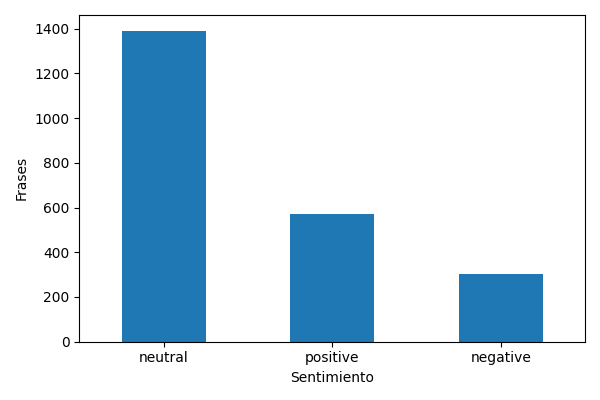

In [4]:
dataframe["target"].value_counts().plot.bar(figsize=(6, 4), rot=0)
plt.xlabel("Sentimiento")
plt.ylabel("Frases")
plt.tight_layout()
plt.show()

In [5]:
from sklearn.model_selection import train_test_split

config = {"ngram_range": [1, 2], "sublinear_tf": True, "C": 2.0,
          "test_size": 0.2, "random_state": 42, "sklearn": sklearn.__version__}
(submission / "config.json").write_text(json.dumps(config, indent=2))

x_train, x_test, y_train, y_test = train_test_split(
    dataframe["phrase"], dataframe["target"], test_size=config["test_size"],
    random_state=config["random_state"], stratify=dataframe["target"],
)

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC

@cache.cache
def entrenar(frases, target, config):
    vectorizer = TfidfVectorizer(
        ngram_range=tuple(config["ngram_range"]), sublinear_tf=config["sublinear_tf"],
    )
    features = vectorizer.fit_transform(frases)
    clf = LinearSVC(C=config["C"], random_state=config["random_state"])
    clf.fit(features, target)
    return vectorizer, clf

vectorizer, clf = entrenar(x_train, y_train, config)

In [7]:
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

y_pred = clf.predict(vectorizer.transform(x_test))
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy de prueba: {accuracy:.4f}")
print(classification_report(y_test, y_pred, zero_division=0))

Accuracy de prueba: 0.9360
              precision    recall  f1-score   support

    negative       0.96      0.84      0.89        61
     neutral       0.95      0.99      0.97       278
    positive       0.88      0.87      0.88       114

    accuracy                           0.94       453
   macro avg       0.93      0.90      0.91       453
weighted avg       0.94      0.94      0.94       453



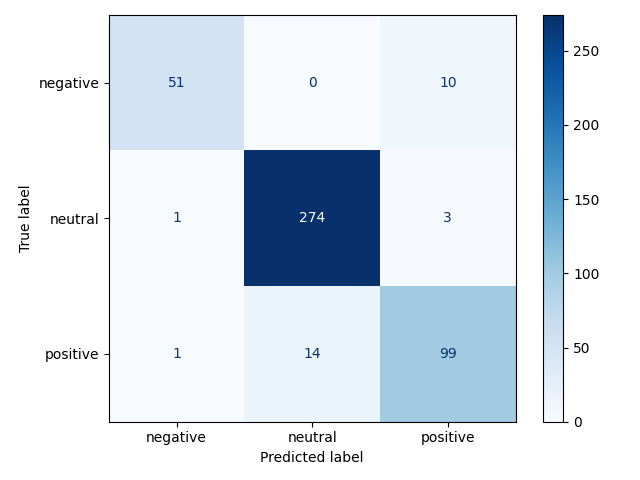

In [8]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues")
plt.tight_layout()
plt.show()

In [9]:
pd.DataFrame({"phrase": x_test, "real": y_test, "prediccion": y_pred}).head(10)

,phrase,real,prediccion
198,The company 's operating income ( EBIT ) total...,positive,positive
1234,"Glaston 's own glass processing unit , Tamglas...",neutral,neutral
2198,"In September alone , the market declined by 10...",negative,positive
559,Goodwill and other intangible assets account f...,neutral,neutral
402,Major Order in India Comptel Corporation has r...,positive,positive
306,"Helsinki on October 22 , 2008 SSH COMMUNICATIO...",neutral,neutral
1511,The shares shall be acquired according to the ...,neutral,neutral
416,Finnish flexible packaging manufacturer Suomin...,positive,positive
1523,The transaction is subject to a final agreemen...,neutral,neutral
1823,The total capacity of the factory will be appr...,neutral,neutral


In [10]:
for nombre, objeto in {"clf.pkl": clf, "vectorizer.pkl": vectorizer}.items():
    with (submission / nombre).open("wb") as archivo:
        pickle.dump(objeto, archivo)
pd.Series({"accuracy_prueba": accuracy}).to_csv(submission / "metricas.csv")